# [AI강의 II] 3회차 월말평가

## Solution.ipynb 파일

이 노트북은 AI 월말평가 정답을 작성하는 목적으로 작성 되었습니다.  
각 문제에 대한 설명은 두 곳에서 확인할 수 있습니다.
  1. 월말평가 문제 PDF 파일 (학사사이트): 각 문제의 목표와 배점
  2. 월말평가 Solution.ipynb: 각 문제에 대한 상세 설명

문제 설명에 대한 정답은 지금 보고 계신 Solution.ipynb 에 작성합니다.
  - 제출: Solution.ipynb 파일만 압축해서 제출합니다.
  - 자세한 제출 방법은 월말평가 문제 PDF 파일을 참고해 주세요

소스코드는 Reference.ipynb 를 참고하여 작성해주세요.

## 유의사항

👉 작성 전 반드시 아래 사항을 확인하세요.

- 문제 설명을 잘 읽고, `# 여기에 코드를 작성합니다` 와 같은 주석이 달린 영역에 코드를 작성하세요.

- 모든 코드는 실행했을 때 에러가 없어야 합니다.
- 코드 실행은 각 셀 단위로 가능합니다.

`ChatGPT 등 온라인 생성형 AI 서비스 및 Local LLM 사용은 강력히 금지합니다`

## 필수 Library 설치 안내

- SSAFY에서 공식적으로 배포한 Dockerfile Set을 기반으로 시험에 응시해야합니다. (ssafy_ai_2.zip)
- 아래 명시된 Library / Package 외 추가 설치를 금합니다.

In [1]:
!pip install -q "seaborn>=0.13.2"

---

## Problem 01: 데이터 생성 프롬프팅

- 주어진 user_prompt 변수에 프롬프트를 작성합니다.

- 총 두 개의 프롬프트를 작성해야 합니다.
  1. 데이터 증강을 통해 10개의 데이터를 생성할 수 있도록 프롬프트를 작성합니다.
  2. 데이터를 합성하여 10개의 데이터를 생성할 수 있도록 프롬프트를 작성합니다.

- 세부 사항은 다음과 같습니다.

### Problem 01-1) 데이터 증강

#### 문제 설명

```
데이터 증강을 목적으로 프롬프트를 아래와 같이 작성하였습니다.

그런데, 제대로 된 결과가 나오지 않았습니다.

few-shot 과 페르소나를 적절히 사용하여, 데이터 증강 목적에 맞는 새로운 문장 10개를 만들 수 있도록 프롬프트를 개선해야 합니다.

또한, 작성한 프롬프트를 모델에 넣었을 때 모델의 답변이 부가 설명 없이 10개의 데이터만 출력되어야 합니다.

원문: 오늘은 너무 즐거워
```

#### 정답 예시

```
- 오늘은 매우 즐겁다
- 오늘 하루가 너무 행복하다
- 오늘은 웃음이 가득한 날이다
- 오늘은 즐거움 그 자체다
- 오늘은 기쁨의 날이다
- 오늘은 정말 재미있었다
- 오늘은 행복감이 가득하다
- 오늘은 너무 기쁘다
- 오늘은 즐거운 시간이었다
- 오늘은 매우 행복했다
```

#### 답안 작성

In [ ]:
# 아래 프롬프트를 수정합니다.
user_prompt = """
너는 문장 데이터를 전문으로 생성하는 AI이다.

주어진 입력 데이터의 문장과 의미는 유사하지만, 표현은 다양하게 하여 여러 데이터를 출력해야 한다.

[예시]
입력 : 오늘 정말 기분 좋은 날이야.
출력 :
오늘 정말 최고의 날이야.
오늘 진짜 행복해.
오늘 진짜 굉장한 날이야.

이제 아래의 주어진 입력을 기반으로 의미는 유사하지만 다양한 표현을 가진 문장 10개를 생성한다.
입력: 오늘은 너무 즐거워

조건:
- 의미는 반드시 같아야 하며, 표현만 다양하게 바꾸어서 출력한다.
- 출력은 반드시 10개의 문장을 출력한다.
- 각 문장은 줄바꿈을 하여 출력한다.
"""

### Problem 01-2) CoT 프롬프트 엔지니어링 고도화

#### 문제 설명

```
Problem 01-1에서는 "오늘은 너무 즐거워"라는 문장을 기반으로
의미를 유지한 채 표현을 다양하게 바꾸는 데이터 증강을 수행하였습니다.

이번에는 문장과 감정(label)을 함께 포함하는 데이터셋을 생성하고자 합니다.

예시는 다음과 같습니다.
{sentence: "오늘 밥은 정말 맛있었어", label: "positive"}
{sentence: "오늘은 몸이 안 좋아", label: "negative"}

Chain-of-Thought와 페르소나를 활용하여,
"오늘은 너무 즐거워"와 유사한 맥락의 다양한 문장을 생성하고,
각 문장에 대해 감정(label)을 함께 포함한 데이터 10개를 생성할 수 있도록
프롬프트를 개선해주시기 바랍니다.

프롬프트에는 모델이 문장의 의미와 감정을 먼저 판단한 후,
이를 기반으로 데이터를 생성하도록 단계적인 사고 과정을 유도하는
Chain-of-Thought 구조가 포함되어야 합니다.

또한, 최종 출력은 부가 설명 없이 JSON 형식의 데이터 10개만 제시되어야 합니다.
```

#### 정답 예시

```
{
  "sentence": "오늘의 파티는 정말 재미있었습니다.",
  "label": "positive"
}

{
  "sentence": "내 친구들이랑 함께한 시간은 정말 행복했습니다.",
  "label": "positive"
}

...

{
  "sentence": "새로운 음식점에서 먹은 음식이 정말 맛있었습니다.",
  "label": "positive"
}
```

#### 답안 작성

In [ ]:
# 아래 프롬프트를 수정합니다.
user_prompt = """
{sentence: "오늘은 너무 즐거워", label: "positive"} 처럼 10개의 문장을 만들어줘
JSON 으로 답변해

너는 감정 분석과 문장 데이터 생성에 탁월한 능력을 가진 전문 AI이다.

주어진 문장에 대해서 맥락은 유사하게 가져가되, 각 문장의 감정을 포함한 데이터를 생성해야 한다.

다음의 사고과정을 참고한다.
[사고 과정]
1. 문장을 단어 단위로 쪼갠다.
2. 단어들에 대한 의미를 먼저 파악한다.
3. 그와 유사한 의미를 가지고 있지만 다른 표현을 가지고 있는 단어들을 찾는다.
4. 새롭게 찾은 단어들을 이용해서 새로운 문장을 조합한다.

아래의 입력을 기반으로 10개의 데이터를 출력한다.
입력 : 오늘은 너무 즐거워

조건:
- json 형태로 출력한다.
- "sentence" 키 값은 생성한 문장 데이터가 들어가야 하고, "label" 키 값은 생성한 문장에 대한 감정 데이터가 들어가야 한다.
- "label"의 키 값은 "positive"와 "negative" 두 값만을 사용해야 한다.
- 입력받은 문장과 유사한 맥락, 감정을 유지하되 다양한 표현으로 생성해야 한다.
- 10개의 데이터를 출력한다.
"""

---

## Problem 02: EDA와 선형회귀

- penguins 데이터를 분석하고, 회귀분석을 통해 데이터 예측을 하고자 합니다.

- 펭귄(penguins) 데이터는 다음과 같은 정보가 있습니다.
  - `species` : 펭귄 종 (Adelie, Chinstrap, Gentoo)
  - `island` : 관측 섬 이름
  - `bill_length_mm` : 부리 길이(mm)
  - `bill_depth_mm` : 부리 깊이(mm)
  - `flipper_length_mm` : 날개 길이(mm)
  - `body_mass_g` : 몸무게(g)
  - `sex` : 성별 (male, female)

- 요구사항에 맞는 EDA 분석과 적절한 코드를 작성합니다.

### Problem 02-1) 데이터 불러오기

#### 문제 설명

- seaborn의 `penguins` 데이터를 불러옵니다.

- 상위 10개의 데이터를 출력합니다.
  - 모든 필드값(column)이 출력되어야 합니다.

#### 답안 작성

In [4]:
# 이곳에 코드를 작성하시오.
import seaborn as sns

df = sns.load_dataset("penguins")
print(df)


    species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0    Adelie  Torgersen            39.1           18.7              181.0   
1    Adelie  Torgersen            39.5           17.4              186.0   
2    Adelie  Torgersen            40.3           18.0              195.0   
3    Adelie  Torgersen             NaN            NaN                NaN   
4    Adelie  Torgersen            36.7           19.3              193.0   
..      ...        ...             ...            ...                ...   
339  Gentoo     Biscoe             NaN            NaN                NaN   
340  Gentoo     Biscoe            46.8           14.3              215.0   
341  Gentoo     Biscoe            50.4           15.7              222.0   
342  Gentoo     Biscoe            45.2           14.8              212.0   
343  Gentoo     Biscoe            49.9           16.1              213.0   

     body_mass_g     sex  
0         3750.0    Male  
1         3800.0  Female  
2     

### Problem 02-2) 컬럼별 결측치 개수 확인

#### 문제 설명

- 적절한 메서드를 활용하여, 각 컬럼별 결측치 개수를 출력합니다.

  - 결측치를 확인할 수 있는 코드라면, 어떤 코드라도 괜찮습니다.

#### 답안 작성

In [6]:
# 이곳에 코드를 작성하시오.

print(df.isnull().sum())


species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


### Problem 02-3) 상관계수 출력하기

#### 문제 설명

penguins 데이터셋에서 `body_mass_g` 변수와 다른 수치형 변수 간의 상관관계를 분석하고자 합니다.  

다음 조건을 만족하는 코드를 작성하세요.

- 전처리  
  - 결측치가 포함된 행은 제거하세요.  

- 상관계수 계산  
  - 수치형 변수만 선택하여 `body_mass_g`와의 상관계수를 계산하세요.  
  - `body_mass_g` 자신과의 상관계수는 제외하세요.  

- 결과 출력  
  - 계산된 상관계수를 **내림차순으로 정렬하여 출력**하세요.

#### 답안 작성

In [48]:
# 이곳에 코드를 작성하시오.
df = df.dropna()
# print(df)

corr = df.corr(numeric_only=True)["body_mass_g"].drop("body_mass_g")
print(corr.sort_values(ascending=False))



flipper_length_mm    0.872979
bill_length_mm       0.589451
bill_depth_mm       -0.472016
Name: body_mass_g, dtype: float64


### Problem 02-4) 시각화

#### 문제 설명

- 부리 길이(`bill_length_mm`)와 몸무게(`body_mass_g`) 두 변수 간의 관계를 적절한 시각화 라이브러리를 사용해 그래프로 나타내세요.

- 추세선을 추가하여 두 변수의 관계를 더 명확히 표현하세요.
  - 추세선을 확인할 수 있다면, 어떠한 차트를 활용해도 무방합니다.

#### 답안 작성

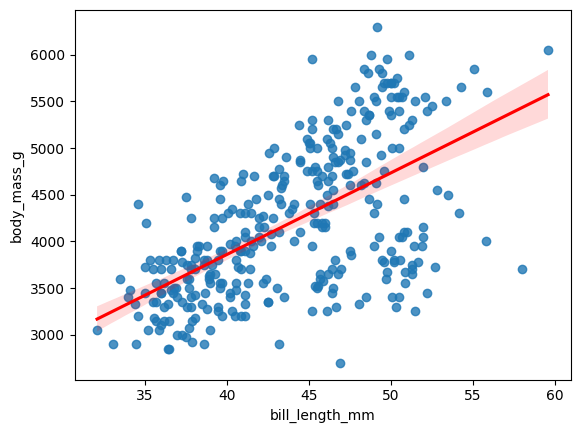

In [9]:
# 이곳에 코드를 작성하시오.
import matplotlib.pyplot as plt

sns.regplot(x="bill_length_mm", y="body_mass_g", data=df, line_kws={"color": "red"})

plt.show()

### Problem 02-5) 분류 모델 구현

#### 문제 설명

- seaborn의 penguins 데이터셋을 활용하여 펭귄의 종(species)을 분류하는 모델을 구현하고자 합니다.

- 아래 코드의 빈칸을 채워 전체 학습 과정을 완성하세요.

  - `___` 로 빈칸이 표시되어 있습니다.


#### 답안 작성

In [15]:
# 이곳에 코드를 작성하시오.
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

df = sns.load_dataset("penguins")

df = df.dropna()

X = df[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']]
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 아래에 적절한 코드를 작성합니다.
model = LogisticRegression(max_iter=100)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")


Accuracy: 0.9851


/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


---

## Problem 03 : RAG 기술의 구현

- RAG 의 전체 흐름을 이해하고, 고객센터 정보를 참고하는 RAG 시스템을 구현하고자 합니다.


### Problem 03-1) RAG 동작 원리 설명하기

#### 문제 설명

- 다음 키워드를 모두 사용하여 RAG 전체 동작 원리를 설명하세요.


- 키워드
```
프롬프트 / LLM / 청킹 / 데이터 생성 / Vector DB / 임베딩 / 유사도 검색
```

#### 답안 작성

In [2]:
# result 변수에 주어진 키워드를 모두 사용하여 RAG 전체 흐름을 자세히 적으세요.
result = f"""
RAG란 문서를 청킹하여 나온 조각들을 임베딩 하여 Vector DB에 저장하고,
들어온 질문에 대해서도 질문을 임베딩하여 유사도 검색을 통해서 관련 문서를 탐색한다.
탐색한 관련 문서를 포함한 프롬프트를 LLM에 넘겨주면 데이티 생성 방식을 통해 답변을 생성하게 된다.
"""

print(result)


RAG란 문서를 청킹하여 나온 조각들을 임베딩 하여 Vector DB에 저장하고,
들어온 질문에 대해서도 질문을 임베딩하여 유사도 검색을 통해서 관련 문서를 탐색한다.
탐색한 관련 문서를 포함한 프롬프트를 LLM에 넘겨주면 데이티 생성 방식을 통해 답변을 생성하게 된다.



### Problem 03-2) LangGraph RAG 흐름 완성하기

#### 문제 설명

- LangGraph를 활용하여 RAG(Retrieval-Augmented Generation) 시스템을 구현하였습니다.

- 검색(retrieve)과 응답 생성(generate)을 위한 각 노드는 정상적으로 정의되어 있습니다.

- 하지만, 노드 간의 흐름을 구성하는 그래프 연결 코드가 완성되지 않아 전체 시스템이 동작하지 않습니다.

- 제시된 코드 중 적절한 코드만을 선택하여, retrieve -> generate -> 종료(END) 흐름이 되도록 올바른 순서로 배치하시기 바랍니다.

  - 주어진 코드 외의 추가 작성은 하지 않습니다.

  - 모든 코드를 반드시 사용할 필요는 없으며, 필요한 코드만 선택하여 사용합니다.

- 주석 아래 부분에 코드를 추가하면 됩니다.

#### 답안 작성

#### 보기
  - 아래 코드 중 적절한 코드를 선택하여 올바른 순서로 배치합니다.

    ```
    graph.add_edge("generate", END)

    graph.add_node("generate", generate)

    graph = StateGraph(State)

    result = app.invoke({
        "question": "LangGraph가 뭐야?",
        "context": "",
        "answer": ""
    })

    graph.add_edge("retrieve", START)

    app = graph.compile()

    graph.set_entry_point("retrieve")

    graph.add_edge("retrieve", "generate")

    graph.add_edge(START, "retrieve")

    graph.add_node("retrieve", retrieve)

    graph.set_entry_point("generate")

    graph.add_edge("retrieve", END)

    graph.add_node("END", END)

    graph.add_edge("generate", "retrieve")
    ```

In [136]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

class State(TypedDict):
    question: str
    context: str
    answer: str

def retrieve(state: State):
    return {"context": "검색 결과"}

def generate(state: State):
    return {"answer": "최종 답변"}

# -------------------------------------------
# 적절한 코드만을 선택하여 올바른 순서로 배치하세요.
# -------------------------------------------

graph = StateGraph(State)
graph.add_node("retrieve", retrieve)
graph.add_node("generate", generate)
# graph.add_node("END", END)

graph.add_edge(START, "retrieve")
graph.add_edge("retrieve", "generate")
graph.add_edge("generate", END)

app = graph.compile()
result = app.invoke({
    "question": "LangGraph가 뭐야?",
    "context": "",
    "answer": ""
})



# 결과 출력
for key, value in result.items():
    print(f"{key}: {value}")


question: LangGraph가 뭐야?
context: 검색 결과
answer: 최종 답변


#### 코드 수행 결과 예시

```
question: LangGraph가 뭐야?
context: 검색 결과
answer: 최종 답변
```